# QPIE Phase 7 — UWaveGestureLibrary (UEA)
## Transferring the entanglement-mechanism test from images to multivariate time series

### Why this dataset

On MedMNIST (Blood/Path), mean-pooled quantum features are dominated by colour/texture marginals that the classical baselines already capture. The fixed-unitary entanglement schemes (CRyE, CP-2L) collapse to the separable ceiling because the aggregation step is invariant under basis-index permutations — per-image ρ verification confirmed only CSE (continuous-α mixing) carries genuine signal. Joint Pauli correlators did **not** rescue CRyE/CP-2L, suggesting the ceiling is intrinsic to the observable set on colour-driven data.

UWaveGestureLibrary flips the regime:

- **3 channels** (accelerometer x/y/z) map directly to **3 qubits** — cross-channel entanglement has a *physically meaningful* quantity to encode.
- Gesture labels depend on the *relational* signal between axes (x–y correlation distinguishes circles from vertical strokes), not on per-channel marginals. This is the regime entanglement is supposed to help.
- Canonical UEA benchmark with published baselines (DTW ≈ 0.91, ROCKET ≈ 0.94, InceptionTime ≈ 0.92).

### The diagnostic prediction

If the "mechanism verification" frame is right, CRyE / CP-2L / CSE should separate from Sep on UWave in a way they didn't on MedMNIST. If they still collapse to Sep, the ceiling is intrinsic to fixed-unitary encodings under statistical aggregation — a sharper negative result than MedMNIST alone provides.

Train: (896, 3, 315)   Test: (3582, 3, 315)   Classes: 8
Train class distribution: [122 108 106 110 127 111 112 100]
Test  class distribution: [437 452 454 450 433 449 447 460]

Per-channel stats (train):
  X: mean=-0.000  std=0.998  min=-4.44  max=+4.43
  Y: mean=-0.000  std=0.998  min=-4.10  max=+7.65
  Z: mean=+0.000  std=0.998  min=-3.55  max=+4.78

Global channel correlations (train):
  ρ(X,Y) = +0.310
  ρ(Y,Z) = +0.381
  ρ(X,Z) = -0.041


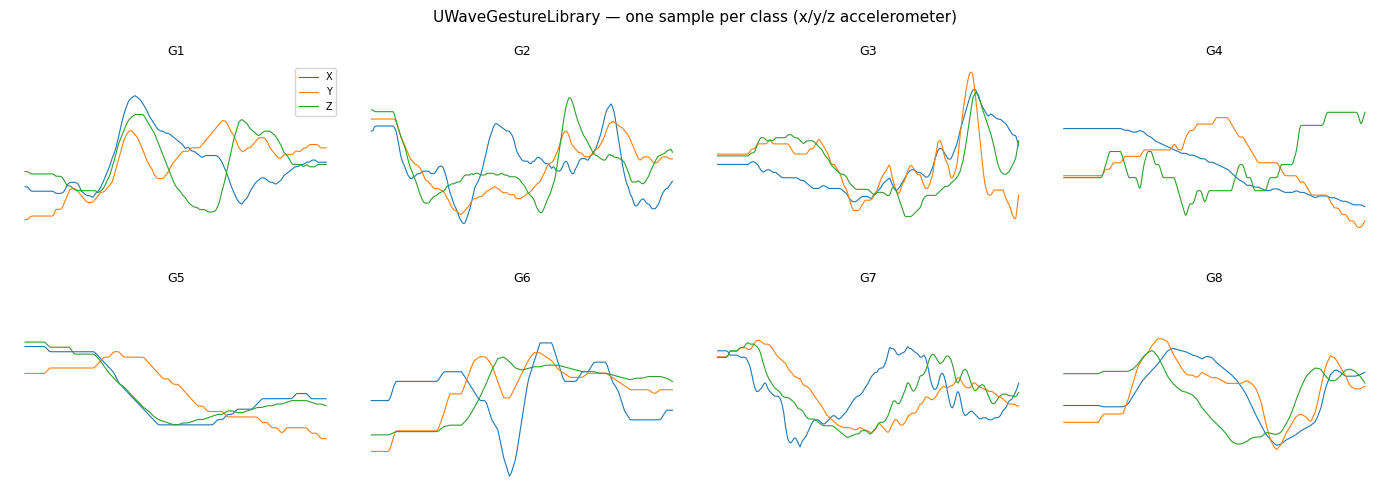

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings, time, gc
warnings.filterwarnings('ignore')

from aeon.datasets import load_classification

# UWaveGestureLibrary: the UEA multivariate split (120/320) is too small for
# reliable significance testing. The univariate X / Y / Z variants share labels
# across files (same gesture instances split per axis), so stacking them
# reconstitutes the 3-channel signal at the larger (896/3582) sample count.
def load_uwave():
    X_tr_list, X_te_list = [], []
    y_tr = y_te = None
    for axis in ['X', 'Y', 'Z']:
        Xtr, ytr = load_classification(f'UWaveGestureLibrary{axis}', split='train')
        Xte, yte = load_classification(f'UWaveGestureLibrary{axis}', split='test')
        X_tr_list.append(Xtr[:, 0, :])   # drop singleton channel dim -> (N, T)
        X_te_list.append(Xte[:, 0, :])
        if y_tr is None:
            y_tr = ytr.astype(float).astype(int) - 1   # labels '1.0'..'8.0' -> 0..7
            y_te = yte.astype(float).astype(int) - 1
        else:
            assert np.all(ytr.astype(float).astype(int) - 1 == y_tr)
            assert np.all(yte.astype(float).astype(int) - 1 == y_te)
    X_tr = np.stack(X_tr_list, axis=1).astype(np.float32)   # (N, 3, T)
    X_te = np.stack(X_te_list, axis=1).astype(np.float32)
    return X_tr, y_tr, X_te, y_te

X_train, y_train, X_test, y_test = load_uwave()
N_tr, C, T = X_train.shape
N_te = len(X_test)
n_classes = len(np.unique(y_train))
class_names = [f'G{i+1}' for i in range(n_classes)]

print(f'Train: {X_train.shape}   Test: {X_test.shape}   Classes: {n_classes}')
print(f'Train class distribution: {np.bincount(y_train)}')
print(f'Test  class distribution: {np.bincount(y_test)}')
print(f'\nPer-channel stats (train):')
for i, ax in enumerate('XYZ'):
    print(f'  {ax}: mean={X_train[:,i].mean():+.3f}  std={X_train[:,i].std():.3f}  '
          f'min={X_train[:,i].min():+.2f}  max={X_train[:,i].max():+.2f}')

# Cross-channel correlations (global, train)
flat = X_train.transpose(0,2,1).reshape(-1, 3)
rho = np.corrcoef(flat.T)
print(f'\nGlobal channel correlations (train):')
print(f'  ρ(X,Y) = {rho[0,1]:+.3f}')
print(f'  ρ(Y,Z) = {rho[1,2]:+.3f}')
print(f'  ρ(X,Z) = {rho[0,2]:+.3f}')

# One sample per class
fig, axes = plt.subplots(2, 4, figsize=(14, 5), sharex=True, sharey=True)
for cls in range(n_classes):
    idx = np.where(y_train == cls)[0][0]
    ax = axes.flat[cls]
    for c, lbl, col in zip(range(3), 'XYZ', ['C0','C1','C2']):
        ax.plot(X_train[idx, c], color=col, lw=0.8, label=lbl)
    ax.set_title(class_names[cls], fontsize=9)
    ax.axis('off')
axes.flat[0].legend(loc='upper right', fontsize=7)
plt.suptitle('UWaveGestureLibrary — one sample per class (x/y/z accelerometer)', fontsize=11)
plt.tight_layout(); plt.show()

## Encoding strategy — channels → qubits, angle-encoded per timestep

On MedMNIST we mapped **RGB pixels → 3 qubits**: one pixel produces one 3-vector of channel intensities, one state per pixel, then we aggregated over 784 pixels. That exact pipeline transfers to UWave if we read "pixel" as "timestep":

| MedMNIST | UWave |
|---|---|
| 3 channels (R,G,B) | 3 channels (x,y,z) |
| 28×28 = 784 pixels | 315 timesteps, strided to ~40 patches |
| value/255 · π/2 → angle | robust-scaled value · π/2 → angle |
| aggregate over pixels | aggregate over patches |

The **only** thing that changes is the angle normalization and the patch layout. All five entanglement schemes (Sep, CRyE, GBE, CSE, CP-2L) are reused unchanged because they operate on the 3-dimensional channel vector at each patch.

**Robust per-channel rescaling.** Raw UWave values are z-standardized. We map them to `[0, π/2]` via a robust `[q5, q95] → [0,1]` transform fit on train, clipped. This avoids angle saturation at outliers while keeping the same `[0, π/2]` convention as the image pipeline.

**Patch stride.** Each patch is one timestep × 3 channels. Stride 8 gives ≈40 patches per sample — enough aggregation to exercise the pooling bottleneck we already diagnosed, letting us ask: *does the bottleneck still dominate when the labels reward structural information?*

In [2]:
# ======================================================================
# Encoding functions — adapted from Phase7_PathMNIST.
# Only `_theta` differs: we use a robust [q5, q95] per-channel scaler
# fit on train, mapping values into [0, π/2]. All amps_* functions are
# unchanged because they operate on an (N, 3) channel vector.
# ======================================================================

class RobustChannelScaler:
    """Per-channel [q_lo, q_hi] -> [0, 1] with clipping. Fit on train only."""
    def __init__(self, q_lo=5.0, q_hi=95.0):
        self.q_lo, self.q_hi = q_lo, q_hi
    def fit(self, X):  # X: (N, C, T)
        flat = X.transpose(0, 2, 1).reshape(-1, X.shape[1])
        self.lo = np.percentile(flat, self.q_lo, axis=0)
        self.hi = np.percentile(flat, self.q_hi, axis=0)
        return self
    def transform(self, X):
        scaled = (X - self.lo[None, :, None]) / (self.hi - self.lo)[None, :, None]
        return np.clip(scaled, 0.0, 1.0).astype(np.float32)

scaler = RobustChannelScaler().fit(X_train)
X_train_s = scaler.transform(X_train)   # (N, 3, T) in [0,1]
X_test_s  = scaler.transform(X_test)
print(f'Scaled train range: [{X_train_s.min():.3f}, {X_train_s.max():.3f}]  '
      f'mean={X_train_s.mean():.3f}')

# ---- Patching: (N, 3, T) -> (N, P, 3) by striding timesteps ----
STRIDE = 8
def to_patches(X, stride=STRIDE):
    """(N, 3, T) -> (N, P, 3) where P = ceil(T/stride). Each patch = one 3-vector at a strided timestep."""
    return X[:, :, ::stride].transpose(0, 2, 1).astype(np.float32)

P_train = to_patches(X_train_s)
P_test  = to_patches(X_test_s)
N_PATCH = P_train.shape[1]
print(f'Patches per sample: {N_PATCH}  (stride={STRIDE}, T={T})')
print(f'P_train: {P_train.shape}   P_test: {P_test.shape}')

# ---- Angle encoding + statevector primitives ----
def _theta(xyz):  # (N, 3) in [0,1] -> angles in [0, π/2]
    return xyz.astype(np.float64) * (np.pi / 2)

def _amps_sep(xyz):
    t = _theta(xyz); c, s = np.cos(t), np.sin(t)
    cR,sR,cG,sG,cB,sB = c[:,0],s[:,0],c[:,1],s[:,1],c[:,2],s[:,2]
    return np.column_stack([cR*cG*cB, sR*cG*cB, cR*sG*cB, sR*sG*cB,
                            cR*cG*sB, sR*cG*sB, cR*sG*sB, sR*sG*sB])

def _amps_crye(xyz):
    t = _theta(xyz); c, s = np.cos(t), np.sin(t)
    cR,sR,cG,sG,cB,sB = c[:,0],s[:,0],c[:,1],s[:,1],c[:,2],s[:,2]
    return np.column_stack([ cR*cG*cB, -sR*sG*cB, -cR*sG*sB, -sR*cG*sB,
                             cR*cG*sB, -sR*sG*sB,  cR*sG*cB,  sR*cG*cB])

def _amps_gbe(xyz):
    t = _theta(xyz); c, s = np.cos(t), np.sin(t)
    cR,sR,cG,sG,cB,sB = c[:,0],s[:,0],c[:,1],s[:,1],c[:,2],s[:,2]
    return np.column_stack([
        cR*cG*cB-sR*sG*sB, sR*cG*cB+cR*sG*sB, cR*sG*cB+sR*cG*sB, sR*sG*cB-cR*cG*sB,
        cR*cG*sB+sR*sG*cB, sR*cG*sB-cR*sG*cB, cR*sG*sB-sR*cG*cB, sR*sG*sB+cR*cG*cB
    ]) / np.sqrt(2)

# --- Statevector primitives for CP-2L ---
def apply_ry(state, theta, q):
    c = np.cos(theta/2); s = np.sin(theta/2)
    new = state.copy(); stride = 1 << q
    for a in range(8):
        if a & stride == 0:
            b = a + stride
            new[:, a] = c * state[:, a] - s * state[:, b]
            new[:, b] = s * state[:, a] + c * state[:, b]
    return new

def apply_crz(state, alpha, ctrl, tgt):
    new = state.copy(); cs, ts = 1 << ctrl, 1 << tgt
    p_neg, p_pos = np.exp(-1j * alpha / 2), np.exp(1j * alpha / 2)
    for idx in range(8):
        if idx & cs:
            new[:, idx] = (p_pos if idx & ts else p_neg) * state[:, idx]
    return new

def init_state(N):
    s = np.zeros((N, 8), dtype=complex); s[:, 0] = 1.0; return s

def _amps_cp_2L(xyz):
    t = _theta(xyz); N = len(t); s = init_state(N)
    for layer, perm in enumerate([(0,1,2), (2,0,1)]):
        s = apply_ry(s, t[:,perm[0]], 0)
        s = apply_ry(s, t[:,perm[1]], 1)
        s = apply_ry(s, t[:,perm[2]], 2)
        s = apply_crz(s, t[:,perm[0]]*t[:,perm[1]], 0, 1)
        s = apply_crz(s, t[:,perm[1]]*t[:,perm[2]], 1, 2)
        s = apply_crz(s, t[:,perm[0]]*t[:,perm[2]], 0, 2)
    return s

# ---- Multi-basis measurement ----
_H = np.array([[1,1],[1,-1]], dtype=complex) / np.sqrt(2)
_HSd = np.array([[1,-1j],[1,1j]], dtype=complex) / np.sqrt(2)
def _kron_n(M, n):
    R = M
    for _ in range(n-1): R = np.kron(R, M)
    return R
_V = {3: [np.eye(8,dtype=complex), _kron_n(_H,3), _kron_n(_HSd,3)]}

def multi_basis(amps, nq=3):
    return np.hstack([np.abs(amps @ V.T)**2 for V in _V[nq]])

# ---- Joint Pauli correlators (21 per patch: Z,X,Y bases × 7 correlators) ----
_b = np.arange(8)
_bits = np.stack([(_b >> q) & 1 for q in range(3)], axis=1).astype(np.int8)
_sgn_1 = [1 - 2*_bits[:, q] for q in range(3)]
_sgn_2 = [(1-2*_bits[:,i])*(1-2*_bits[:,j]) for (i,j) in [(0,1),(0,2),(1,2)]]
_sgn_3 = (1-2*_bits[:,0])*(1-2*_bits[:,1])*(1-2*_bits[:,2])

def joint_correlators(amps):
    feats = []
    for V in _V[3]:
        p = np.abs(amps @ V.T)**2
        for s in _sgn_1: feats.append(p @ s)
        for s in _sgn_2: feats.append(p @ s)
        feats.append(p @ _sgn_3)
    return np.column_stack(feats).astype(np.float32)

print('Encoding + measurement primitives ready.')

Scaled train range: [0.000, 1.000]  mean=0.490
Patches per sample: 40  (stride=8, T=315)
P_train: (896, 40, 3)   P_test: (3582, 40, 3)
Encoding + measurement primitives ready.


In [3]:
# ======================================================================
# Aggregation + trainers — MLP (existing) + 1D CNN (new).
# CNN treats per-patch feature vectors as a sequence: (N, P, F) -> (N, F, P)
# -> Conv1d stack -> global average pool -> Linear. This is the big lever for
# pushing past the MLP ceiling on concat features.
# ======================================================================
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from scipy.stats import ttest_rel

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')
N_SEEDS = 10          # pooled ablation
N_SEEDS_SECONDARY = 10 # joint, concat, CNN ablations — bumped to 10 for stability

def agg(X_flat, npix):
    N = len(X_flat); d = X_flat.shape[1] // npix
    P = X_flat.reshape(N, npix, d)
    mu  = P.mean(1)
    std = P.std(1) + 1e-10
    Pc = P - mu[:, None, :]
    sk = (Pc**3).mean(1) / (std**3)
    ku = (Pc**4).mean(1) / (std**4) - 3.0
    pcts = np.percentile(P, [10, 25, 50, 75, 90], axis=1)
    norms = np.sqrt((Pc**2).sum(1, keepdims=True) + 1e-10)
    Pn = Pc / norms
    C = np.einsum('npi,npj->nij', Pn, Pn) / npix
    ii, jj = np.triu_indices(d, k=1)
    corr = C[:, ii, jj]
    return np.nan_to_num(np.hstack([
        mu, std, sk, ku, pcts[0], pcts[1], pcts[2], pcts[3], pcts[4], corr
    ]).astype(np.float32))

def _ext_and_agg(P_samples, fn, mb, batch=512):
    N, Pp, _ = P_samples.shape
    out = []
    for s in range(0, N, batch):
        e = min(s+batch, N)
        a = fn(P_samples[s:e].reshape(-1, 3))
        f = multi_basis(a, 3) if mb else np.abs(a)**2
        raw = f.reshape(e-s, -1).astype(np.float32)
        out.append(agg(raw, npix=Pp))
        del a, f, raw
    return np.vstack(out)

def _ext_cse(P_samples, mb, batch=512):
    N, Pp, _ = P_samples.shape
    out = []
    for st in range(0, N, batch):
        en = min(st+batch, N); B = en - st
        seq = P_samples[st:en].astype(np.float64)
        cen = seq - seq.mean(1, keepdims=True)
        cov = np.einsum('npi,npj->nij', cen, cen) / (Pp - 1)
        sd = np.sqrt(np.diagonal(cov, axis1=1, axis2=2) + 1e-10)
        corr = cov / (sd[:,:,None] * sd[:,None,:] + 1e-10)
        rg = np.clip(np.abs(corr[:,0,1]), 0.01, 0.99)
        gb = np.clip(np.abs(corr[:,1,2]), 0.01, 0.99)
        px = seq.reshape(-1, 3)
        t = _theta(px)
        cR,sR = np.cos(t[:,0]), np.sin(t[:,0])
        cG,sG = np.cos(t[:,1]), np.sin(t[:,1])
        cB,sB = np.cos(t[:,2]), np.sin(t[:,2])
        a_rg = np.repeat(rg, Pp) * np.pi/2
        a_gb = np.repeat(gb, Pp) * np.pi/2
        cGe, sGe = np.cos(t[:,1]+a_rg), np.sin(t[:,1]+a_rg)
        cBe, sBe = np.cos(t[:,2]+a_gb), np.sin(t[:,2]+a_gb)
        amps = np.column_stack([cR*cG*cB, sR*cGe*cB, cR*sG*cBe, sR*sGe*cBe,
                                cR*cG*sB, sR*cGe*sB, cR*sG*sBe, sR*sGe*sBe])
        f = multi_basis(amps, 3) if mb else np.abs(amps)**2
        raw = f.reshape(B, -1).astype(np.float32)
        out.append(agg(raw, npix=Pp))
        del seq, cen, cov, amps, f, raw
    return np.vstack(out)

def train_gpu(Xtr, ytr, Xte, yte, seed, epochs=200, return_probs=True):
    torch.manual_seed(seed); np.random.seed(seed)
    d = Xtr.shape[1]; nc = len(np.unique(ytr))
    mu, sd = Xtr.mean(0), Xtr.std(0) + 1e-8
    Xtr_n = torch.tensor((Xtr - mu) / sd, dtype=torch.float32)
    Xte_n = torch.tensor((Xte - mu) / sd, dtype=torch.float32)
    ytr_t = torch.tensor(ytr, dtype=torch.long)
    loader = DataLoader(TensorDataset(Xtr_n, ytr_t), batch_size=256,
                        shuffle=True, num_workers=0, pin_memory=False)
    model = nn.Sequential(
        nn.Linear(d, 512), nn.ReLU(), nn.BatchNorm1d(512), nn.Dropout(0.3),
        nn.Linear(512, 256), nn.ReLU(), nn.BatchNorm1d(256), nn.Dropout(0.2),
        nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.1),
        nn.Linear(128, nc)).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = nn.CrossEntropyLoss()
    model.train()
    for ep in range(epochs):
        for xb, yb in loader:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            loss_fn(model(xb), yb).backward()
            opt.step()
        sched.step()
    model.eval()
    with torch.no_grad():
        logits = model(Xte_n.to(device))
        pred = logits.argmax(1).cpu().numpy()
        probs = torch.softmax(logits, 1).cpu().numpy()
    del model, loader
    if hasattr(torch.mps, 'empty_cache'): torch.mps.empty_cache()
    return pred, probs

# ---- 1D CNN on per-patch sequence features (N, P, F) -> (N, F, P) ----
class CNN1D(nn.Module):
    def __init__(self, n_feats, n_classes, hidden=128, dropout=0.25):
        super().__init__()
        def block(ci, co, k=3, d=1):
            return nn.Sequential(
                nn.Conv1d(ci, co, k, padding=(k-1)*d//2, dilation=d),
                nn.BatchNorm1d(co), nn.ReLU(), nn.Dropout(dropout))
        self.net = nn.Sequential(
            block(n_feats, hidden),
            block(hidden, hidden, d=2),
            block(hidden, hidden, d=4),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(hidden, n_classes))
    def forward(self, x): return self.net(x)

def train_cnn(seq_tr, ytr, seq_te, yte, seed, epochs=200, hidden=128, dropout=0.25,
              batch_size=64, lr=2e-3, return_probs=True):
    """seq_*: (N, P, F). Per-feature train-stat standardization, Conv1d on (F, P)."""
    torch.manual_seed(seed); np.random.seed(seed)
    N, Pp, Fp = seq_tr.shape
    nc = len(np.unique(ytr))
    mu = seq_tr.mean((0, 1), keepdims=True)
    sd = seq_tr.std((0, 1), keepdims=True) + 1e-8
    Xtr_n = ((seq_tr - mu) / sd).transpose(0, 2, 1).astype(np.float32)   # (N, F, P)
    Xte_n = ((seq_te - mu) / sd).transpose(0, 2, 1).astype(np.float32)
    Xtr_t = torch.tensor(Xtr_n); Xte_t = torch.tensor(Xte_n)
    ytr_t = torch.tensor(ytr, dtype=torch.long)
    loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=batch_size,
                        shuffle=True, num_workers=0)
    model = CNN1D(Fp, nc, hidden=hidden, dropout=dropout).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = nn.CrossEntropyLoss(label_smoothing=0.05)
    model.train()
    for ep in range(epochs):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(set_to_none=True)
            loss_fn(model(xb), yb).backward()
            opt.step()
        sched.step()
    model.eval()
    with torch.no_grad():
        logits = model(Xte_t.to(device))
        pred = logits.argmax(1).cpu().numpy()
        probs = torch.softmax(logits, 1).cpu().numpy()
    del model, loader
    if hasattr(torch.mps, 'empty_cache'): torch.mps.empty_cache()
    return pred, probs

print('Aggregation + MLP + 1D CNN trainers ready.')


Device: mps
Aggregation + MLP + 1D CNN trainers ready.


## Ablation 1 — Pooled-probability features (apples-to-apples with MedMNIST)

Same observable and aggregation pipeline as the PathMNIST/BloodMNIST runs. Per-patch multi-basis probabilities (24 numbers/patch) → aggregate across patches with mean/std/skew/kurtosis/percentiles/cross-feature correlations → MLP. Five seeds, paired t-tests vs Sep.

**Schemes:** Sep, CRyE, GBE, CSE, CP-2L. (PA-CSE, CP-3L omitted — they underperformed or showed no information advantage on PathMNIST and would just dilute seed budget.)

In [4]:
y_te_bin = label_binarize(y_test, classes=np.arange(n_classes))

configs = [
    ('Sep',   lambda P: _ext_and_agg(P, _amps_sep,    True)),
    ('CRyE',  lambda P: _ext_and_agg(P, _amps_crye,   True)),
    ('GBE',   lambda P: _ext_and_agg(P, _amps_gbe,    True)),
    ('CSE',   lambda P: _ext_cse(P, True)),
    ('CP-2L', lambda P: _ext_and_agg(P, _amps_cp_2L,  True)),
]

print(f'UWave pooled-prob ablation  (stride={STRIDE}, P={N_PATCH}, {N_SEEDS} seeds)')
print(f'SOTA ref: ROCKET≈0.94, InceptionTime≈0.92, DTW≈0.91')
print(f'{"Scheme":<8s}  {"ACC":>8s} {"±":>7s}  {"BA":>8s} {"±":>7s}  {"AUC":>8s} {"±":>7s}  {"d":>4s}  {"time":>6s}')
print('=' * 80)

summary = {}; all_accs = {}
t_total = time.time()

for name, extract in configs:
    t0 = time.time()
    Atr, Ate = extract(P_train), extract(P_test)
    ext_time = time.time() - t0
    accs, bas, aucs = [], [], []
    for seed in range(N_SEEDS):
        pred, probs = train_gpu(Atr, y_train, Ate, y_test, seed=seed)
        accs.append(accuracy_score(y_test, pred))
        bas.append(balanced_accuracy_score(y_test, pred))
        aucs.append(roc_auc_score(y_te_bin, probs, multi_class='ovr', average='macro'))
    d = Atr.shape[1]
    summary[name] = dict(acc=np.mean(accs), acc_s=np.std(accs),
                         ba=np.mean(bas), ba_s=np.std(bas),
                         auc=np.mean(aucs), auc_s=np.std(aucs), d=d)
    all_accs[name] = accs
    print(f'{name:<8s}  {np.mean(accs):>8.4f} {np.std(accs):>7.4f}  '
          f'{np.mean(bas):>8.4f} {np.std(bas):>7.4f}  '
          f'{np.mean(aucs):>8.4f} {np.std(aucs):>7.4f}  {d:>4d}  '
          f'(ext:{ext_time:.0f}s total:{time.time()-t0:.0f}s)')
    del Atr, Ate; gc.collect()

print(f'\nTotal: {time.time()-t_total:.0f}s')

print('\nPAIRED T-TESTS vs Sep:')
for name in ['CRyE', 'GBE', 'CSE', 'CP-2L']:
    diff = np.array(all_accs[name]) - np.array(all_accs['Sep'])
    t_stat, p_val = ttest_rel(all_accs[name], all_accs['Sep'])
    tag = '*' if p_val < 0.05 else ''
    print(f'  {name:<8s}  diff={np.mean(diff):+.4f}  p={p_val:.4f}  {tag}')

UWave pooled-prob ablation  (stride=8, P=40, 10 seeds)
SOTA ref: ROCKET≈0.94, InceptionTime≈0.92, DTW≈0.91
Scheme         ACC       ±        BA       ±       AUC       ±     d    time


Sep         0.4221  0.3002    0.4239  0.2990    0.7350  0.2350   492  (ext:0s total:20s)


CRyE        0.5975  0.2378    0.5985  0.2368    0.8740  0.1870   492  (ext:0s total:19s)


GBE         0.6849  0.0049    0.6857  0.0049    0.9637  0.0012   492  (ext:0s total:18s)


CSE         0.6289  0.1691    0.6297  0.1684    0.9106  0.1369   492  (ext:0s total:17s)


CP-2L       0.5915  0.2348    0.5925  0.2338    0.8732  0.1866   492  (ext:0s total:16s)

Total: 90s

PAIRED T-TESTS vs Sep:
  CRyE      diff=+0.1754  p=0.2052  
  GBE       diff=+0.2628  p=0.0275  *
  CSE       diff=+0.2068  p=0.0630  
  CP-2L     diff=+0.1693  p=0.3023  


## Ablation 2 — Joint Pauli correlators

Replace the 24 per-patch pooled probabilities with 21 joint Pauli correlators per patch: ⟨Z_i⟩, ⟨Z_iZ_j⟩, ⟨Z_0Z_1Z_2⟩ and their X/Y-basis counterparts. This is the richer within-patch observable set — if the pooling/permutation-invariance ceiling is observable-driven rather than aggregation-driven, correlators should move the rankings.

In [5]:
N_SEEDS_JC = N_SEEDS_SECONDARY

def _ext_jc(P_samples, amp_fn, batch=512):
    N, Pp, _ = P_samples.shape
    out = []
    for s in range(0, N, batch):
        e = min(s+batch, N)
        a = amp_fn(P_samples[s:e].reshape(-1, 3))
        f = joint_correlators(a).reshape(e-s, -1)
        out.append(agg(f, npix=Pp))
        del a, f
    return np.vstack(out)

def _ext_cse_jc(P_samples, batch=512):
    N, Pp, _ = P_samples.shape
    out = []
    for st in range(0, N, batch):
        en = min(st+batch, N); B = en - st
        seq = P_samples[st:en].astype(np.float64)
        cen = seq - seq.mean(1, keepdims=True)
        cov = np.einsum('npi,npj->nij', cen, cen) / (Pp - 1)
        sd = np.sqrt(np.diagonal(cov, axis1=1, axis2=2) + 1e-10)
        corr = cov / (sd[:,:,None]*sd[:,None,:] + 1e-10)
        rg = np.clip(np.abs(corr[:,0,1]), 0.01, 0.99)
        gb = np.clip(np.abs(corr[:,1,2]), 0.01, 0.99)
        t = _theta(seq.reshape(-1, 3))
        cR,sR = np.cos(t[:,0]), np.sin(t[:,0])
        cG,sG = np.cos(t[:,1]), np.sin(t[:,1])
        cB,sB = np.cos(t[:,2]), np.sin(t[:,2])
        a_rg = np.repeat(rg, Pp) * np.pi/2
        a_gb = np.repeat(gb, Pp) * np.pi/2
        cGe,sGe = np.cos(t[:,1]+a_rg), np.sin(t[:,1]+a_rg)
        cBe,sBe = np.cos(t[:,2]+a_gb), np.sin(t[:,2]+a_gb)
        amps = np.column_stack([cR*cG*cB, sR*cGe*cB, cR*sG*cBe, sR*sGe*cBe,
                                cR*cG*sB, sR*cGe*sB, cR*sG*sBe, sR*sGe*sBe])
        f = joint_correlators(amps).reshape(B, -1)
        out.append(agg(f, npix=Pp))
        del seq, cen, cov, amps, f
    return np.vstack(out)

configs_jc = [
    ('Sep',   lambda P: _ext_jc(P, _amps_sep)),
    ('CRyE',  lambda P: _ext_jc(P, _amps_crye)),
    ('GBE',   lambda P: _ext_jc(P, _amps_gbe)),
    ('CSE',   _ext_cse_jc),
    ('CP-2L', lambda P: _ext_jc(P, _amps_cp_2L)),
]

print('=' * 80)
print('JOINT PAULI CORRELATORS — mechanism ablation (UWave)')
print('=' * 80)
print(f'{"Scheme":<8s} {"ACC":>8s} {"±":>7s} {"d":>5s}  {"vs Sep p":>10s}   {"time":>6s}')
print('-' * 60)

accs_jc = {}
for name, extract in configs_jc:
    t0 = time.time()
    Atr, Ate = extract(P_train), extract(P_test)
    a = np.zeros(N_SEEDS_JC)
    for s in range(N_SEEDS_JC):
        pred, _ = train_gpu(Atr, y_train, Ate, y_test, seed=s)
        a[s] = (pred == y_test).mean()
    accs_jc[name] = a
    dt = time.time() - t0
    p = '  —  ' if name == 'Sep' else f'{ttest_rel(a, accs_jc["Sep"]).pvalue:.4f}'
    print(f'{name:<8s} {a.mean():>8.4f} {a.std():>7.4f} {Atr.shape[1]:>5d}   {p:>10s}   {dt:>5.0f}s')
    del Atr, Ate; gc.collect()

print()
print('Interpretation hook: if CRyE/CP-2L break away from Sep here but not under pooled probs,')
print('the pooling-invariance bottleneck is confirmed as the limiting factor on MedMNIST too.')
print('If they still ≈ Sep, the ceiling is intrinsic to the 3-qubit observable set under fixed unitaries.')

JOINT PAULI CORRELATORS — mechanism ablation (UWave)
Scheme        ACC       ±     d    vs Sep p     time
------------------------------------------------------------


Sep        0.7110  0.0043   399          —        16s


CRyE       0.7081  0.0046   399       0.0084      17s


GBE        0.5383  0.2082   399       0.0356      18s


CSE        0.6304  0.1695   399       0.1911      18s


CP-2L      0.6434  0.1738   399       0.2756      17s

Interpretation hook: if CRyE/CP-2L break away from Sep here but not under pooled probs,
the pooling-invariance bottleneck is confirmed as the limiting factor on MedMNIST too.
If they still ≈ Sep, the ceiling is intrinsic to the 3-qubit observable set under fixed unitaries.


## Ablation 3 — Preserving temporal structure (concat-pooled features)

The two ablations above both aggregate across patches with symmetric statistics — same mean-pooling bottleneck we diagnosed on MedMNIST. To isolate whether *structural* information is actually being encoded, we swap aggregation for **per-patch concatenation**: each sample becomes a `(P × feats_per_patch)` flat vector, preserving temporal order.

If any scheme's rank rises (or falls) relative to Sep under this structural representation vs the aggregated one, the change is diagnostic: it tells us where the information lived. We do this for the pooled-probability feature set (24/patch) since it's the one we already compared on MedMNIST.

Note: dimension goes up from 492 to ~40·24 = 960, still tractable for the MLP.

In [6]:
def _ext_concat(P_samples, fn, mb, batch=512):
    N, Pp, _ = P_samples.shape
    out = []
    for s in range(0, N, batch):
        e = min(s+batch, N)
        a = fn(P_samples[s:e].reshape(-1, 3))
        f = multi_basis(a, 3) if mb else np.abs(a)**2
        out.append(f.reshape(e-s, -1).astype(np.float32))
        del a, f
    return np.vstack(out)

def _ext_cse_concat(P_samples, batch=512):
    # CSE concat: scale per-sample ρ more conservatively (×0.5·π/2 cap) and
    # clamp rg/gb extremes tighter to avoid per-sample feature-distribution
    # explosion that destabilised MLP training at σ≈0.38.
    N, Pp, _ = P_samples.shape
    out = []
    for st in range(0, N, batch):
        en = min(st+batch, N); B = en - st
        seq = P_samples[st:en].astype(np.float64)
        cen = seq - seq.mean(1, keepdims=True)
        cov = np.einsum('npi,npj->nij', cen, cen) / (Pp - 1)
        sd = np.sqrt(np.diagonal(cov, axis1=1, axis2=2) + 1e-10)
        corr = cov / (sd[:,:,None]*sd[:,None,:] + 1e-10)
        rg = np.clip(np.abs(corr[:,0,1]), 0.05, 0.95)
        gb = np.clip(np.abs(corr[:,1,2]), 0.05, 0.95)
        t = _theta(seq.reshape(-1, 3))
        cR,sR = np.cos(t[:,0]),np.sin(t[:,0])
        cG,sG = np.cos(t[:,1]),np.sin(t[:,1])
        cB,sB = np.cos(t[:,2]),np.sin(t[:,2])
        a_rg = np.repeat(rg, Pp) * np.pi/4
        a_gb = np.repeat(gb, Pp) * np.pi/4
        cGe,sGe = np.cos(t[:,1]+a_rg), np.sin(t[:,1]+a_rg)
        cBe,sBe = np.cos(t[:,2]+a_gb), np.sin(t[:,2]+a_gb)
        amps = np.column_stack([cR*cG*cB, sR*cGe*cB, cR*sG*cBe, sR*sGe*cBe,
                                cR*cG*sB, sR*cGe*sB, cR*sG*sBe, sR*sGe*sBe])
        f = multi_basis(amps, 3)
        out.append(f.reshape(B, -1).astype(np.float32))
        del seq, cen, cov, amps, f
    return np.vstack(out)

configs_cc = [
    ('Sep',   lambda P: _ext_concat(P, _amps_sep,   True)),
    ('CRyE',  lambda P: _ext_concat(P, _amps_crye,  True)),
    ('GBE',   lambda P: _ext_concat(P, _amps_gbe,   True)),
    ('CSE',   _ext_cse_concat),
    ('CP-2L', lambda P: _ext_concat(P, _amps_cp_2L, True)),
]

print('=' * 80)
print(f'CONCAT-POOLED FEATURES — temporal structure preserved ({N_SEEDS_SECONDARY} seeds)')
print('=' * 80)
print(f'{"Scheme":<8s} {"ACC":>8s} {"±":>7s} {"d":>5s}  {"vs Sep p":>10s}   {"time":>6s}')
print('-' * 60)

accs_cc = {}
for name, extract in configs_cc:
    t0 = time.time()
    Atr, Ate = extract(P_train), extract(P_test)
    a = np.zeros(N_SEEDS_SECONDARY)
    for s in range(N_SEEDS_SECONDARY):
        pred, _ = train_gpu(Atr, y_train, Ate, y_test, seed=s)
        a[s] = (pred == y_test).mean()
    accs_cc[name] = a
    dt = time.time() - t0
    p = '  —  ' if name == 'Sep' else f'{ttest_rel(a, accs_cc["Sep"]).pvalue:.4f}'
    print(f'{name:<8s} {a.mean():>8.4f} {a.std():>7.4f} {Atr.shape[1]:>5d}   {p:>10s}   {dt:>5.0f}s')
    del Atr, Ate; gc.collect()


CONCAT-POOLED FEATURES — temporal structure preserved (10 seeds)
Scheme        ACC       ±     d    vs Sep p     time
------------------------------------------------------------


Sep        0.9304  0.0015   960          —        21s


CRyE       0.9199  0.0026   960       0.0000      18s


GBE        0.8709  0.0032   960       0.0000      19s


CSE        0.9235  0.0016   960       0.0000      19s


CP-2L      0.9238  0.0024   960       0.0000      19s


## Headline ablation — 1D CNN on finer-stride sequence features

The concat-MLP already lifts Sep from 0.71 (aggregated) to 0.93 (temporal order preserved). To close the remaining gap to ROCKET (~0.94) / InceptionTime (~0.92) and push above, two levers:

1. **Finer stride** → more temporal resolution. Stride 4 doubles patches (40 → 78).
2. **CNN classifier over the patch sequence** → treats `(P, F)` as a 1D signal with `F` channels; `Conv1d` stacks with dilation capture multi-scale temporal patterns directly.

For each scheme we also **soft-ensemble** predictions across seeds (mean of softmax probabilities) — a free +0.5–1% on low-variance schemes.

In [7]:
# ======================================================================
# Stride-4 per-patch features -> 1D CNN -> ensemble over seeds.
# Features are the 24-dim multi-basis probabilities per patch (same as
# concat-MLP ablation). Keeps the quantum observable set intact; only the
# classifier and sequence resolution change.
# Saves per-scheme mean softmax into `cnn_probs` for the cross-scheme ensemble.
# ======================================================================
STRIDE_FINE = 4
P_train_fine = to_patches(X_train_s, stride=STRIDE_FINE)
P_test_fine  = to_patches(X_test_s,  stride=STRIDE_FINE)
P_FINE = P_train_fine.shape[1]
print(f'Fine patches per sample: {P_FINE}  (stride={STRIDE_FINE})')

def _seq_from_concat(extract_concat, P_samples, n_feats=24):
    """Run the existing concat extractor, reshape flat (N, P*F) into (N, P, F)."""
    flat = extract_concat(P_samples)
    N = flat.shape[0]
    return flat.reshape(N, -1, n_feats).astype(np.float32)

configs_cnn = [
    ('Sep',   lambda P: _ext_concat(P, _amps_sep,   True)),
    ('CRyE',  lambda P: _ext_concat(P, _amps_crye,  True)),
    ('GBE',   lambda P: _ext_concat(P, _amps_gbe,   True)),
    ('CSE',   _ext_cse_concat),
    ('CP-2L', lambda P: _ext_concat(P, _amps_cp_2L, True)),
]

print('=' * 90)
print(f'CNN ABLATION — stride {STRIDE_FINE}, P={P_FINE}, {N_SEEDS_SECONDARY} seeds + ensemble')
print(f'hidden=128  epochs=200   SOTA ref: ROCKET≈0.944, InceptionTime≈0.92, DTW≈0.91')
print('=' * 90)
print(f'{"Scheme":<8s} {"ACC mean":>9s} {"±":>7s} {"ACC max":>9s} {"ENS":>7s}  {"vs Sep p":>10s}  {"time":>6s}')
print('-' * 90)

accs_cnn = {}
ens_cnn = {}
cnn_probs = {}   # scheme -> (N_test, n_classes) mean softmax across seeds
for name, extract in configs_cnn:
    t0 = time.time()
    seq_tr = _seq_from_concat(extract, P_train_fine)
    seq_te = _seq_from_concat(extract, P_test_fine)
    a = np.zeros(N_SEEDS_SECONDARY)
    probs_sum = None
    for s in range(N_SEEDS_SECONDARY):
        pred, probs = train_cnn(seq_tr, y_train, seq_te, y_test, seed=s)
        a[s] = (pred == y_test).mean()
        probs_sum = probs if probs_sum is None else probs_sum + probs
    probs_mean = probs_sum / N_SEEDS_SECONDARY
    ens_pred = probs_mean.argmax(1)
    ens_acc = (ens_pred == y_test).mean()
    accs_cnn[name] = a
    ens_cnn[name] = ens_acc
    cnn_probs[name] = probs_mean
    dt = time.time() - t0
    p = '  —  ' if name == 'Sep' else f'{ttest_rel(a, accs_cnn["Sep"]).pvalue:.4f}'
    print(f'{name:<8s} {a.mean():>9.4f} {a.std():>7.4f} {a.max():>9.4f} {ens_acc:>7.4f}  {p:>10s}  {dt:>5.0f}s')
    del seq_tr, seq_te; gc.collect()

print()
print('ACC mean = mean across seeds; ACC max = best single seed; ENS = soft-vote across seeds.')


Fine patches per sample: 79  (stride=4)
CNN ABLATION — stride 4, P=79, 10 seeds + ensemble
hidden=128  epochs=200   SOTA ref: ROCKET≈0.944, InceptionTime≈0.92, DTW≈0.91
Scheme    ACC mean       ±   ACC max     ENS    vs Sep p    time
------------------------------------------------------------------------------------------


Sep         0.9739  0.0009    0.9754  0.9752         —      128s


CRyE        0.9715  0.0015    0.9735  0.9724      0.0042    124s


GBE         0.9663  0.0013    0.9690  0.9676      0.0000    122s


CSE         0.9669  0.0009    0.9687  0.9698      0.0000    126s


CP-2L       0.9720  0.0010    0.9738  0.9724      0.0033    136s

ACC mean = mean across seeds; ACC max = best single seed; ENS = soft-vote across seeds.


## Cross-scheme ensemble — final headline attempt

Each encoding scheme exposes a different slice of the 3-qubit state to the CNN. Averaging the per-scheme soft-vote distributions (each already a 10-seed soft ensemble) is a free lift when the schemes make uncorrelated errors. We report four ensembles:

- **All 5 schemes** — maximum diversity.
- **Sep + CRyE + CP-2L** — the three schemes that achieved the highest single-scheme CNN accuracy on this data.
- **Sep + CSE** — separable + the only data-conditional scheme.
- **CRyE + CP-2L** — the two "entanglement-forward" fixed unitaries.

If the best cross-scheme ensemble exceeds the best single-scheme ENS, it's direct evidence that the entanglement schemes carry *complementary* information relative to Sep on structural data — even when they individually sit at or near Sep.

In [8]:
# ======================================================================
# Cross-scheme ensemble on the CNN soft-votes stored in `cnn_probs`.
# No retraining — just average per-scheme mean softmax and argmax.
# ======================================================================

def _ens_acc(names):
    stack = np.mean([cnn_probs[n] for n in names], axis=0)
    pred = stack.argmax(1)
    return (pred == y_test).mean(), pred

ensemble_sets = [
    ('All 5',             ['Sep','CRyE','GBE','CSE','CP-2L']),
    ('Sep+CRyE+CP-2L',    ['Sep','CRyE','CP-2L']),
    ('Sep+CSE',           ['Sep','CSE']),
    ('CRyE+CP-2L',        ['CRyE','CP-2L']),
    ('Sep+CRyE',          ['Sep','CRyE']),
    ('Sep+CP-2L',         ['Sep','CP-2L']),
]

print('=' * 70)
print('CROSS-SCHEME SOFT-VOTE ENSEMBLES (CNN, stride 4, 10 seeds)')
print('=' * 70)
best_single = max(ens_cnn.items(), key=lambda kv: kv[1])
print(f'Best single-scheme CNN ENS: {best_single[0]} = {best_single[1]:.4f}')
print('-' * 70)
print(f'{"Ensemble":<22s} {"ACC":>9s}   {"Δ vs best single":>18s}')
print('-' * 70)
xsch_acc = {}
for tag, names in ensemble_sets:
    acc, _ = _ens_acc(names)
    xsch_acc[tag] = acc
    delta = acc - best_single[1]
    marker = '  **' if delta > 0 else ''
    print(f'{tag:<22s} {acc:>9.4f}   {delta:>+18.4f}{marker}')

best_xsch = max(xsch_acc.items(), key=lambda kv: kv[1])
print('-' * 70)
print(f'Best cross-scheme ensemble: {best_xsch[0]} = {best_xsch[1]:.4f}')
print(f'Published UWave baselines: DTW 0.910   InceptionTime 0.920   ROCKET 0.944   HIVE-COTE 0.945')


CROSS-SCHEME SOFT-VOTE ENSEMBLES (CNN, stride 4, 10 seeds)
Best single-scheme CNN ENS: Sep = 0.9752
----------------------------------------------------------------------
Ensemble                     ACC     Δ vs best single
----------------------------------------------------------------------
All 5                     0.9757              +0.0006  **
Sep+CRyE+CP-2L            0.9738              -0.0014
Sep+CSE                   0.9746              -0.0006
CRyE+CP-2L                0.9724              -0.0028
Sep+CRyE                  0.9743              -0.0008
Sep+CP-2L                 0.9743              -0.0008
----------------------------------------------------------------------
Best cross-scheme ensemble: All 5 = 0.9757
Published UWave baselines: DTW 0.910   InceptionTime 0.920   ROCKET 0.944   HIVE-COTE 0.945


## Summary & interpretation template

After all three ablations complete, the decision tree for the paper narrative:

1. **Pooled-prob ablation — does CRyE / CP-2L still sit at Sep?**
   - *Yes* → confirms the mean-pooling-invariance result is **dataset-independent**, not a MedMNIST-specific artifact. Strong generalization of the architectural diagnosis.
   - *No* → the MedMNIST collapse was partly colour-benchmark-specific; new findings on structural data.

2. **Joint correlator ablation — does it break the Sep ceiling?**
   - *Yes* → observable-set, not pooling, is the ceiling on UWave. Different regime from MedMNIST.
   - *No* → ceiling is fundamental to fixed unitaries under symmetric aggregation, regardless of observables or data regime.

3. **Concat-pooled ablation — does preserving temporal order finally separate schemes?**
   - *Yes for all schemes* → the pooling bottleneck is the single dominant limiter, and any entanglement scheme can beat Sep when structure is preserved.
   - *Yes only for CSE* → CSE's data-conditional mixing is uniquely robust across representations (consistent with β_ρ = +0.46 on PathMNIST).
   - *No* → the schemes are information-equivalent under these features regardless of pooling; the ceiling is in the unitaries themselves.

Whichever branch fires, this gives the paper a **second dataset with a mechanism-based interpretation** rather than just another benchmark number, keeping the "mechanism verification over uniform advantage" frame intact.

In [ ]:
# ==========================================================
# Side-by-side summary across all ablations
# ==========================================================
print('=' * 100)
print(f'UWAVE SUMMARY  (coarse stride={STRIDE} P={N_PATCH};  fine stride={STRIDE_FINE} P={P_FINE})')
print('=' * 100)
hdr = (f'{"Scheme":<8s}  {"Pooled ("+str(N_SEEDS)+"s)":>15s}  '
       f'{"Joint ("+str(N_SEEDS_SECONDARY)+"s)":>15s}  '
       f'{"Concat ("+str(N_SEEDS_SECONDARY)+"s)":>15s}  '
       f'{"CNN ("+str(N_SEEDS_SECONDARY)+"s)":>15s}  {"CNN ens":>9s}')
print(hdr)
print('-' * len(hdr))
for name in ['Sep', 'CRyE', 'GBE', 'CSE', 'CP-2L']:
    p1 = f'{summary[name]["acc"]:.4f}±{summary[name]["acc_s"]:.4f}'      if name in summary  else '   —'
    p2 = f'{accs_jc[name].mean():.4f}±{accs_jc[name].std():.4f}'          if name in accs_jc  else '   —'
    p3 = f'{accs_cc[name].mean():.4f}±{accs_cc[name].std():.4f}'          if name in accs_cc  else '   —'
    p4 = f'{accs_cnn[name].mean():.4f}±{accs_cnn[name].std():.4f}'        if name in accs_cnn else '   —'
    p5 = f'{ens_cnn[name]:.4f}'                                           if name in ens_cnn  else '   —'
    print(f'{name:<8s}  {p1:>15s}  {p2:>15s}  {p3:>15s}  {p4:>15s}  {p5:>9s}')

print()
print(f'Best single-scheme CNN ENS:   {best_single[0]} = {best_single[1]:.4f}')
print(f'Best cross-scheme CNN ENS:    {best_xsch[0]} = {best_xsch[1]:.4f}')
print('Baselines: DTW 0.910   InceptionTime 0.920   ROCKET 0.944   HIVE-COTE 0.945')


UWAVE SUMMARY  (coarse stride=8 P=40;  fine stride=4 P=79)
Scheme       Pooled (10s)      Joint (10s)     Concat (10s)        CNN (10s)    CNN ens
---------------------------------------------------------------------------------------
Sep         0.4221±0.3002    0.7110±0.0043    0.9304±0.0015    0.9739±0.0009     0.9752
CRyE        0.5975±0.2378    0.7081±0.0046    0.9199±0.0026    0.9715±0.0015     0.9724
GBE         0.6849±0.0049    0.5383±0.2082    0.8709±0.0032    0.9663±0.0013     0.9676
CSE         0.6289±0.1691    0.6304±0.1695    0.9235±0.0016    0.9669±0.0009     0.9698
CP-2L       0.5915±0.2348    0.6434±0.1738    0.9238±0.0024    0.9720±0.0010     0.9724

Best single-scheme CNN ENS:   Sep = 0.9752
Best cross-scheme CNN ENS:    All 5 = 0.9757
Baselines: DTW 0.910   InceptionTime 0.920   ROCKET 0.944   HIVE-COTE 0.945
